In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (7745, 44)
Test shape: (1635, 44)


In [3]:
feature_cols = [
    "HomeForm",
    "AwayForm",
    "HomeGoalsAvg5",
    "AwayGoalsAvg5",
    "HomeGoalsConcededAvg5",
    "AwayGoalsConcededAvg5",
    "HomeWinRate5",
    "AwayWinRate5",
    "HomeH2HForm5",
    "HomePosition",
    "AwayPosition",
    "HomeGoalDiff5",
    "AwayGoalDiff5",
    "HomeRestDays",
    "AwayRestDays"
]

In [4]:
X_train = train_df[feature_cols]
y_train = train_df["FullTimeResult"]

X_test = test_df[feature_cols]
y_test = test_df["FullTimeResult"]

In [5]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7745, 15)
X_test: (1635, 15)
y_train: (7745,)
y_test: (1635,)


## 7.3 — Logistic Regression

In [6]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

In [7]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['A','D','H']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['HomeForm','AwayForm','HomeGoalsAvg5',...,'AwayGoalDiff5','HomeRestDays', 'AwayRestDays']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [8]:
y_pred = model.predict(X_test)

In [9]:
print(y_pred[:20])

['H' 'A' 'H' 'A' 'H' 'H' 'H' 'H' 'H' 'A' 'H' 'H' 'H' 'H' 'H' 'H' 'H' 'H'
 'H' 'A']


In [10]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,D,H
1,A,A
2,H,H
3,D,A
4,D,H
5,A,H
6,H,H
7,H,H
8,A,H
9,A,A


In [11]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           A       0.55      0.51      0.53       539
           D       0.40      0.01      0.01       374
           H       0.54      0.84      0.66       722

    accuracy                           0.54      1635
   macro avg       0.50      0.45      0.40      1635
weighted avg       0.51      0.54      0.47      1635



In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["H", "D", "A"]
)

print(cm)

[[608   2 112]
 [259   2 113]
 [265   1 273]]


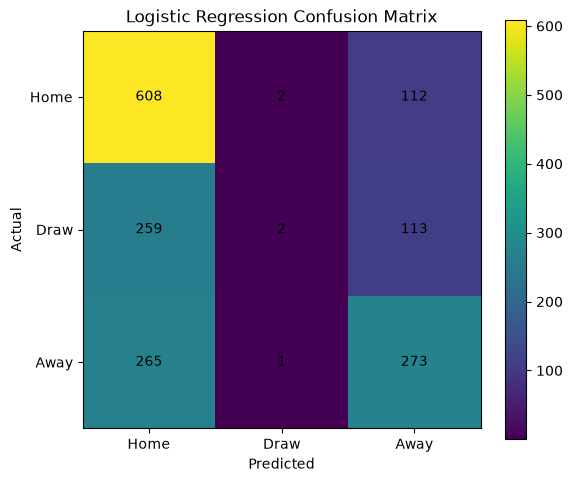

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(3),
    ["Home", "Draw", "Away"]
)

plt.yticks(
    range(3),
    ["Home", "Draw", "Away"]
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

In [14]:
y_pred = model.predict(X_test)

In [15]:
y_prob = model.predict_proba(X_test)

In [16]:
print(model.classes_)

['A' 'D' 'H']


In [17]:
print(y_prob[:5])

[[0.24834988 0.27484741 0.47680272]
 [0.64066694 0.19631278 0.16302028]
 [0.35189334 0.26518917 0.3829175 ]
 [0.5217405  0.2621388  0.2161207 ]
 [0.19546631 0.2508241  0.55370959]]


In [18]:
y_pred = model.predict(X_test)

In [19]:
model.classes_

array(['A', 'D', 'H'], dtype=object)

In [20]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "AwayProb": y_prob[:, 0],
    "DrawProb": y_prob[:, 1],
    "HomeProb": y_prob[:, 2]
})

results.head(10)

,Actual,Predicted,AwayProb,DrawProb,HomeProb
0,D,H,0.248350,0.274847,0.476803
1,A,A,0.640667,0.196313,0.163020
2,H,H,0.351893,0.265189,0.382917
3,D,A,0.521740,0.262139,0.216121
4,D,H,0.195466,0.250824,0.553710
5,A,H,0.311861,0.235906,0.452233
6,H,H,0.246091,0.272204,0.481705
7,H,H,0.178663,0.219583,0.601754
8,A,H,0.351378,0.257359,0.391263
9,A,A,0.572930,0.216540,0.210530


In [21]:
from sklearn.metrics import log_loss

loss = log_loss(
    y_test,
    y_prob,
    labels=model.classes_
)

print("Log Loss:", loss)

Log Loss: 0.9915265572698595


In [22]:
from sklearn.metrics import accuracy_score, log_loss

accuracy = accuracy_score(y_test, y_pred)

loss = log_loss(
    y_test,
    y_prob,
    labels=model.classes_
)

print("Accuracy:", accuracy)
print("Log Loss:", loss)

Accuracy: 0.5400611620795107
Log Loss: 0.9915265572698595


In [23]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "LogLoss": loss
}

baseline_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.5400611620795107,
 'LogLoss': 0.9915265572698595}

In [24]:
accuracy = accuracy_score(y_test, y_pred)

## 7.4 — Random Forest Baseline (No Tuning)

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)

In [26]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           A       0.51      0.43      0.46       539
           D       0.23      0.07      0.11       374
           H       0.53      0.77      0.63       722

    accuracy                           0.50      1635
   macro avg       0.42      0.42      0.40      1635
weighted avg       0.45      0.50      0.45      1635



In [27]:
rf_loss = log_loss(y_test, rf_prob, labels=rf_model.classes_)
print('Random Forest Log Loss:', rf_loss)

Random Forest Log Loss: 1.0228915178786468


## 7.5 — XGBoost Baseline (No Tuning)

In [28]:
from xgboost import XGBClassifier

# Map classes to numeric for XGBoost
class_map = {'A': 0, 'D': 1, 'H': 2}
inv_class_map = {0: 'A', 1: 'D', 2: 'H'}
y_train_num = y_train.map(class_map)
y_test_num = y_test.map(class_map)

xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_num)
xgb_pred_num = xgb_model.predict(X_test)
xgb_pred = pd.Series(xgb_pred_num).map(inv_class_map)
xgb_prob = xgb_model.predict_proba(X_test)

In [29]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           A       0.48      0.42      0.45       539
           D       0.26      0.14      0.18       374
           H       0.52      0.70      0.60       722

    accuracy                           0.48      1635
   macro avg       0.42      0.42      0.41      1635
weighted avg       0.45      0.48      0.45      1635



In [30]:
xgb_loss = log_loss(y_test, xgb_prob, labels=['A', 'D', 'H'])
print('XGBoost Log Loss:', xgb_loss)

XGBoost Log Loss: 1.0815895795822144


## 7.6 — Baseline Models Comparison Table

In [31]:
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(y_true, y_pred, y_prob, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    _, _, wf1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    loss = log_loss(y_true, y_prob)
    return {
        'Model': name,
        'Accuracy': acc,
        'Macro Precision': prec,
        'Macro Recall': rec,
        'Macro F1': f1,
        'Weighted F1': wf1,
        'Log Loss': loss
    }

comparison_data = [
    get_metrics(y_test, y_pred, y_prob, 'Logistic Regression'),  # y_pred and y_prob are LR predictions
    get_metrics(y_test, rf_pred, rf_prob, 'Random Forest'),
    get_metrics(y_test, xgb_pred, xgb_prob, 'XGBoost')
]

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

              Model  Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1  Log Loss
Logistic Regression  0.540061         0.495098      0.451315  0.397651     0.465618  0.991527
      Random Forest  0.498471         0.419383      0.423921  0.399527     0.454114  1.022892
            XGBoost  0.478287         0.421504      0.418798  0.408792     0.452748  1.081590
